# Quantum_FL_RS_general_Ne_Nx

Clean generalized notebook for comparing the many-body Qiskit evolution with the Raffelt--Sigl mean-field evolution for

\[
N_e\;\nu_e + N_x\;\nu_x(\alpha),
\qquad
\nu_x(\alpha)=\cos\alpha\,\nu_e+\sin\alpha\,\nu_\mu .
\]

This is the generalized version of the older fixed \(1\nu_e+15\nu_x\) notebook.

Default choice:

\[
N_e=1,\qquad N_x=15.
\]

To check \(N_e=2\) later, change only `Ne` in Cell 1.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as integ

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

In [13]:
import argparse

parser = argparse.ArgumentParser(
    description="Many-body vs Random-Phase neutrino oscillation simulation"
)

parser.add_argument(
    "--Ne",
    type=int,
    help="Number of initially electron-flavor neutrinos",
)

parser.add_argument(
    "--Nx",
    type=int,
    help="Number of initially x-flavor neutrinos",
)

args, _ = parser.parse_known_args()

if args.Ne is None:
    Ne = int(input("Enter the number of electron-flavor neutrinos (Ne): "))
else:
    Ne = args.Ne

if args.Nx is None:
    Nx = int(input("Enter the number of x-flavor neutrinos (Nx): "))
else:
    Nx = args.Nx

N = Ne + Nx

if Ne < 1 or Nx < 1:
    raise ValueError("Ne and Nx must be positive integers.")

Enter the number of electron-flavor neutrinos (Ne):  2
Enter the number of x-flavor neutrinos (Nx):  8


In [14]:
# =============================
# CELL 1: Imports and parameters
# =============================

# -----------------------------
# Particle numbers
# -----------------------------


# -----------------------------
# Physics parameters
# -----------------------------
E = 1.0
dm2 = 1.0
theta_vac = 0.195

sin_2th = np.sin(2.0 * theta_vac)
cos_2th = np.cos(2.0 * theta_vac)
omega1 = dm2 / (4.0 * E)

bx = omega1 * np.sin(2.0 * theta_vac)
by = 0.0
bz = -omega1 * np.cos(2.0 * theta_vac)

# This is the scale used for the dimensionless time axis t*mu.
mu = 1

# -----------------------------
# Evolution choices
# -----------------------------
# Keep these False to match the later cells of the old e1_x15 notebook:
# self-interaction only, with no vacuum and no matter term.
use_vacuum = False
use_matter = False

# Apply the leading BCH commutator correction to each Trotter step.
use_bch_correction = True

# -----------------------------
# Time / Trotter / sampling parameters
# -----------------------------
dt = 0.025
T_max = 10 #200.0
sample_every = 20

n_steps_max = int(round(T_max / dt))
times = np.arange(0, n_steps_max + 1, sample_every) * dt

# -----------------------------
# Qiskit simulation parameters
# -----------------------------
shots = 4096
seed_simulator = 12345
backend = AerSimulator(seed_simulator=seed_simulator)

# -----------------------------
# Alpha cases
# -----------------------------
alpha_cases = [
    (np.pi/2, r"\pi/2"),
    (np.pi/3, r"\pi/3"),
    (np.pi/4, r"\pi/4"),
    (np.pi/6, r"\pi/6"),
    (0.0,     r"0"),
]

print(f"Using Ne = {Ne}, Nx = {Nx}, total N = {N}")
print(f"omega1 = {omega1}")
print(f"mu = omega1 * N = {mu}")
print(f"Number of sampled times = {len(times)}, T_max = {T_max}, dt = {dt}")
print(f"Evolution mode: self-interaction only = {not use_vacuum and not use_matter}")

Using Ne = 2, Nx = 8, total N = 10
omega1 = 0.25
mu = omega1 * N = 1
Number of sampled times = 21, T_max = 10, dt = 0.025
Evolution mode: self-interaction only = True


In [15]:
# =======================================
# CELL 2: Interaction matrix J_ij
# =======================================



#J = interaction_matrix(N, dm2, E)
J=1.0
#print("J shape =", J.shape)
#print("J min/max =", J.min(), J.max())

In [16]:
# =========================================
# Pauli commutator helper
# =========================================

_PAULI_MUL = {
    ("x", "x"): ("I", 1),
    ("y", "y"): ("I", 1),
    ("z", "z"): ("I", 1),

    ("x", "y"): ("z", 1j),
    ("y", "x"): ("z", -1j),

    ("y", "z"): ("x", 1j),
    ("z", "y"): ("x", -1j),

    ("z", "x"): ("y", 1j),
    ("x", "z"): ("y", -1j),
}


def _pauli_commutator_coefficient(term_a, term_b, N):
    """
    Return (c, P) such that

        [P_a, P_b] = 2 i c P,

    where P_a and P_b are Pauli strings.

    If the two Pauli strings commute, return (0, None).
    """

    phase = 1.0 + 0.0j
    result = {}

    for q in range(N):

        a = term_a.get(q, "I")
        b = term_b.get(q, "I")

        if a == "I" and b == "I":
            continue

        if a == "I":
            result[q] = b
            continue

        if b == "I":
            result[q] = a
            continue

        c, local_phase = _PAULI_MUL[(a, b)]

        phase *= local_phase

        if c != "I":
            result[q] = c

    if np.isclose(phase.real, 0.0) and np.isclose(abs(phase.imag), 1.0):
        return float(phase.imag), tuple(sorted(result.items()))

    return 0.0, None


# =========================================
# Leading BCH correction: TWO-BEAM model
# =========================================

def build_bch_correction_terms(J, Ne, Nx):
    """
    Construct the leading BCH correction for one first-order
    Trotter step in the two-beam model.

    Qubits 0,...,Ne-1 belong to beam 1.
    Qubits Ne,...,Ne+Nx-1 belong to beam 2.

    The interaction Hamiltonian is

        H = J sum_{i in beam 1} sum_{j in beam 2}
              (X_i X_j + Y_i Y_j + Z_i Z_j).

    There are NO same-beam interactions.

    The first-order circuit is ordered as

        (i,j,XX), (i,j,YY), (i,j,ZZ)

    for each cross-beam pair, with i and j traversed in the
    same order as in add_interaction_evolution().

    For the actual Qiskit gate ordering,

        U_T = exp(-i h_m dt) ... exp(-i h_2 dt) exp(-i h_1 dt),

    and therefore

        log(U_T)
          = -i H dt
            + dt^2/2 sum_{a<b} [h_a,h_b]
            + O(dt^3).

    Hence the correction appended after the Trotter step is

        U_corr
          = exp[-dt^2/2 sum_{a<b} [h_a,h_b]].

    Since

        [P_a,P_b] = 2 i c P,

    the correction is implemented as

        exp[-i dt^2 c P].
    """

    N = Ne + Nx
    correction = {}

    pair_terms = []

    # ---------------------------------------------------------
    # Only cross-beam interactions:
    #
    # i = beam 1
    # j = beam 2
    # ---------------------------------------------------------
    for i in range(Ne):
        for j in range(Ne, N):

            # Same fixed scalar coupling J for every pair.
            pair_terms.append((float(J), {i: "x", j: "x"}))
            pair_terms.append((float(J), {i: "y", j: "y"}))
            pair_terms.append((float(J), {i: "z", j: "z"}))

    # ---------------------------------------------------------
    # Calculate
    #
    #   sum_{a<b} [h_a,h_b]
    #
    # = 2 i sum_P c_P P.
    # ---------------------------------------------------------
    for a in range(len(pair_terms)):

        Ja, Pa = pair_terms[a]

        for b in range(a + 1, len(pair_terms)):

            Jb, Pb = pair_terms[b]

            c, P = _pauli_commutator_coefficient(Pa, Pb, N)

            if c != 0.0:
                correction[P] = (
                    correction.get(P, 0.0)
                    + Ja * Jb * c
                )

    # Remove terms whose coefficients cancel exactly.
    return {
        P: c
        for P, c in correction.items()
        if not np.isclose(c, 0.0)
    }


# =========================================
# Arbitrary Pauli-string rotation
# =========================================

def add_pauli_rotation(qc, theta, pauli_string):
    """
    Implement

        exp[-i theta P]

    for an arbitrary Pauli string P.

    Example:

        P = X_0 Z_1 Y_2

    is implemented by changing X/Y into the Z basis,
    accumulating the Z parity with CNOTs, applying RZ(2*theta),
    and undoing the transformation.
    """

    qubits = [q for q, _ in pauli_string]
    paulis = {q: p for q, p in pauli_string}

    # Change X/Y into the Z basis.
    for q in qubits:

        if paulis[q] == "x":
            qc.h(q)

        elif paulis[q] == "y":
            qc.sdg(q)
            qc.h(q)

    # Accumulate parity on the last qubit.
    for q in qubits[:-1]:
        qc.cx(q, qubits[-1])

    # Qiskit convention:
    #
    # RZ(phi) = exp[-i phi Z / 2]
    #
    # Therefore RZ(2*theta) = exp[-i theta Z].
    qc.rz(1.0 * theta, qubits[-1])

    # Undo parity accumulation.
    for q in reversed(qubits[:-1]):
        qc.cx(q, qubits[-1])

    # Undo basis transformations.
    for q in reversed(qubits):

        if paulis[q] == "x":
            qc.h(q)

        elif paulis[q] == "y":
            qc.h(q)
            qc.s(q)


# =========================================
# Apply BCH correction
# =========================================

def add_bch_correction(qc, J, Ne, Nx, dt, correction_terms=None):
    """
    Apply the leading BCH correction after one first-order
    Trotter step.

    For the Qiskit ordering used here,

        theta = +dt^2 * c

    because the desired correction is

        exp[-dt^2/2 sum_{a<b}[h_a,h_b]]

    and

        [P_a,P_b] = 2 i c P.
    """

    if correction_terms is None:
        correction_terms = build_bch_correction_terms(
            J=J,
            Ne=Ne,
            Nx=Nx
        )

    for P, c in correction_terms.items():

        theta = 2 * dt**2 * c

        add_pauli_rotation(
            qc,
            theta,
            P
        )


# =========================================
# Interaction evolution
# =========================================

def add_interaction_evolution(
    qc,
    n,
    J,
    Ne,
    Nx,
    dt,
    use_bch_correction=True
):
    """
    Add n first-order interaction steps for the two-beam model.

    Only particles belonging to different beams interact:

        i in beam 1
        j in beam 2.

    For each cross-beam pair,

        exp[-i J dt (XX + YY + ZZ)]

    is implemented by RXX, RYY and RZZ.

    The leading BCH correction is then appended after
    each first-order Trotter step.
    """

    N = Ne + Nx

    correction_terms = None

    if use_bch_correction:

        correction_terms = build_bch_correction_terms(
            J=J,
            Ne=Ne,
            Nx=Nx
        )

    for _ in range(n):

        # -----------------------------------------------------
        # First-order Lie-Trotter evolution.
        #
        # ONLY cross-beam pairs.
        # -----------------------------------------------------
        for i in range(Ne):

            for j in range(Ne, N):

                phi = 2.0 * J * dt

                qc.rxx(phi, i, j)
                qc.ryy(phi, i, j)
                qc.rzz(phi, i, j)

        # -----------------------------------------------------
        # Leading BCH correction.
        # -----------------------------------------------------
        if use_bch_correction:

            add_bch_correction(
                qc,
                J=J,
                Ne=Ne,
                Nx=Nx,
                dt=dt,
                correction_terms=correction_terms
            )

### Leading BCH correction

For the ordered first-order product
\[
U_T(\delta t)=\prod_a e^{-i h_a\delta t},
\]
the BCH expansion gives
\[
\log U_T
=
-iH\delta t
-\frac{\delta t^2}{2}\sum_{a<b}[h_a,h_b]
+O(\delta t^3).
\]

The modified circuit therefore appends
\[
\exp\!\left[
+\frac{\delta t^2}{2}\sum_{a<b}[h_a,h_b]
\right]
\]
after each first-order Trotter layer.

For \(h_{pq}=J_{pq}(XX+YY+ZZ)\), the \(XX,YY,ZZ\) terms within the same pair commute exactly. The correction comes from overlapping pairs and is represented as three-body Pauli rotations.

Set `use_bch_correction = False` in the parameter cell to recover the original circuit.


In [17]:
# ============================================
# CELL 4: Raffelt--Sigl mean-field solver
# ============================================

# Pauli matrices
sigma_0 = np.array([[1, 0],  [0,  1]], dtype=complex)
sigma_1 = np.array([[0, 1],  [1,  0]], dtype=complex)
sigma_2 = np.array([[0, -1j], [1j, 0]], dtype=complex)
sigma_3 = np.array([[1, 0],  [0, -1]], dtype=complex)


def P_osc_RS(t_table, theta, omega, lam, J, initial_flavors=None, alpha=None):
    """
    Raffelt--Sigl two-flavor polarization-vector evolution.

    Parameters
    ----------
    t_table : array
        Sampled times.
    theta : float
        Vacuum mixing angle.
    omega : array
        Vacuum frequencies for all modes.
    lam : float
        Matter strength.
    J : array
        Coupling matrix.
    initial_flavors : array
        Entries may be:
            'e'  : |nu_e>
            'x'  : |nu_mu>
            'mu' : |nu_mu>
            'a'  : cos(alpha)|nu_e> + sin(alpha)|nu_mu>
    alpha : float
        Superposition angle for every mode labeled 'a'.
    """
    n_modes = omega.size

    u = np.array([[np.cos(theta), np.sin(theta)],
                  [-np.sin(theta), np.cos(theta)]])
    b = 0.5 * np.diag([-1, 1])
    b = u @ b @ u.T
    l = np.diag([1, 0])

    Ee = np.array([0.0, 0.0,  1.0])
    Emu = np.array([0.0, 0.0, -1.0])

    B = np.real(np.array([np.trace(b @ sigma_1),
                          np.trace(b @ sigma_2),
                          np.trace(b @ sigma_3)]))
    L = np.real(np.array([np.trace(l @ sigma_1),
                          np.trace(l @ sigma_2),
                          np.trace(l @ sigma_3)]))

    ini_state = np.where(omega > 0, Ee[:, None], Emu[:, None])

    if initial_flavors is not None:
        initial_flavors = np.asarray(initial_flavors)

        for f in initial_flavors:
            if f not in ["e", "x", "mu", "a"]:
                raise ValueError(f"Unknown flavor label: {f}")
            if f == "a" and alpha is None:
                raise ValueError("Flavor label 'a' requires alpha.")

        ini_state[:, initial_flavors == "e"] = Ee[:, None]
        ini_state[:, initial_flavors == "x"] = Emu[:, None]
        ini_state[:, initial_flavors == "mu"] = Emu[:, None]
        ini_state[:, initial_flavors == "a"] = np.array(
            [np.sin(2.0 * alpha), 0.0, np.cos(2.0 * alpha)]
        )[:, None]

    def rhs(t, P_flat):
        """
        dP_k/dt = H_k x P_k,
        H_k = omega_k B + lambda L + sum_j J_kj P_j.
        """
        res = np.zeros(3 * n_modes)
        PP = np.reshape(P_flat, (n_modes, 3)).T
        
        for k in range(n_modes):
            H_k = omega[k] * B + lam * L + J * np.sum(PP, axis=1)
            res[3*k:3*k+3] = np.cross(H_k, PP[:, k])

        return res
    
    return integ.solve_ivp(
        rhs,
        (t_table[0], t_table[-1]),
        ini_state.T.flatten(),
        t_eval=t_table,
    )

In [18]:
# =====================================================
# CELL 5: Many-body Qiskit solver for Ne + Nx(alpha)
# =====================================================

def prepare_initial_circuit(Ne, Nx, alpha):
    """
    Prepare the initial many-body state:

        first Ne qubits: |nu_e> = |0>
        next  Nx qubits: |nu_x(alpha)> = cos(alpha)|0> + sin(alpha)|1>

    RY(2 alpha)|0> = cos(alpha)|0> + sin(alpha)|1>.

    For alpha = pi/2, the Nx group is exactly |1>, reproducing
    the old 1 nu_e + 15 nu_mu setup when Ne=1, Nx=15.
    """
    N = Ne + Nx
    qc0 = QuantumCircuit(N, N)

    # First Ne qubits are |nu_e> = |0>, so no gate is needed.
    for q in range(Ne, N):
        qc0.ry(2.0 * alpha, q)

    return qc0


def run_many_body_qiskit(alpha, Ne, Nx, J, times, dt, shots, backend,
                         use_vacuum=False, bx=0.0, by=0.0, bz=0.0,
                         verbose=True, use_bch_correction=True):
    """
    Run the many-body Qiskit simulation for a given alpha.

    Output
    ------
    P_bit1[q, k] :
        Probability that qubit q is measured as |1> at time times[k].

    For the first Ne qubits, which start as |nu_e>=|0>,
        P_bit1 = P(nu_e -> nu_mu).

    The plotted observable is the Ne-average:
        <P(nu_e -> nu_mu)> over the initially electron-flavor group.
    """
    N = Ne + Nx
    qc0 = prepare_initial_circuit(Ne, Nx, alpha)

    P_bit1 = [[] for _ in range(N)]

    for t in times:
        n = int(round(t / dt))
        qc = qc0.copy()

        #if use_vacuum:
            #add_vacuum_evolution(qc, n=n, bx=bx, by=by, bz=bz, N=N)

        add_interaction_evolution(
            qc,
            n=n,
            J=J,
            Ne=Ne,
            Nx=Nx,
            dt=dt,
            use_bch_correction=use_bch_correction
        )

        qc.measure(range(N), range(N))

        tqc = transpile(qc, backend, optimization_level=0)
        counts = backend.run(tqc, shots=shots).result().get_counts()

        p1_t = [0.0] * N

        for bitstring, c in counts.items():
            prob = c / shots

            for q in range(N):
                # Qiskit displays bitstrings with the highest classical bit first.
                bit_q = int(bitstring[-1 - q])
                if bit_q == 1:
                    p1_t[q] += prob

        for q in range(N):
            P_bit1[q].append(p1_t[q])

        if verbose:
            print(
                f"alpha={alpha:.6f}, t={t:8.3f}: "
                f"<P_e_to_mu>_MB = {np.mean(p1_t[:Ne]):.5f}"
            )

    P_bit1 = np.array(P_bit1)

    return {
        "P_bit1": P_bit1,
        "P_e_to_mu_avg": np.mean(P_bit1[:Ne, :], axis=0),
    }

In [19]:
# =====================================================
# CELL 6: RS solver and combined alpha-case runner
# =====================================================

def run_rs_mean_field(alpha, Ne, Nx, J, times,
                      use_vacuum=False, use_matter=False):
    """
    Run the Raffelt--Sigl mean-field evolution for the same initial state.

    Default:
        omega = 0,
        lambda = 0,

    so this solves the self-interaction-only mean-field problem, matching
    the old e1_x15 comparison.
    """
    N = Ne + Nx

    if use_vacuum:
        omega = np.ones(N) * omega1
        theta_rs = theta_vac
    else:
        omega = np.zeros(N)
        theta_rs = 0.0

    lam = 1.0 if use_matter else 0.0

    initial_flavors = np.array(["e"] * Ne + ["a"] * Nx)

    sol = P_osc_RS(
        times,
        theta_rs,
        omega,
        lam,
        J,
        initial_flavors=initial_flavors,
        alpha=alpha,
    )

    P_all = sol.y
    P = P_all.reshape(N, 3, -1)
    Pz = P[:, 2, :]

    # P(nu_mu) = (1 - Pz)/2 for each mode.
    P_mu = 0.5 * (1.0 - Pz)

    return {
        "sol": sol,
        "P": P,
        "Pz": Pz,
        "P_mu": P_mu,
        "P_e_to_mu_avg": np.mean(P_mu[:Ne, :], axis=0),
    }


def run_alpha_case(alpha, verbose=True):
    """
    Run both many-body Qiskit and RS mean-field for one alpha.
    """
    N = Ne + Nx
    J = 1.0

    mb = run_many_body_qiskit(
        alpha=alpha,
        Ne=Ne,
        Nx=Nx,
        J=J,
        times=times,
        dt=dt,
        shots=shots,
        backend=backend,
        use_vacuum=use_vacuum,
        bx=bx,
        by=by,
        bz=bz,
        verbose=verbose,
        use_bch_correction=use_bch_correction,
    )

    rs = run_rs_mean_field(
        alpha=alpha,
        Ne=Ne,
        Nx=Nx,
        J=J,
        times=times,
        use_vacuum=use_vacuum,
        use_matter=use_matter,
    )

    return {
        "alpha": alpha,
        "Ne": Ne,
        "Nx": Nx,
        "many_body": mb,
        "rs": rs,
    }

In [20]:
# =====================================================
# CELL 7: Plotting helpers
# =====================================================

results = {}

# Choose the x-axis used in all plots.
# Options:
#     "t"    : physical notebook time
#     "t_mu" : dimensionless t*mu
plot_time_axis = "t"


def get_plot_time():
    if plot_time_axis == "t":
        return times, r"Total time"
    elif plot_time_axis == "t_mu":
        return times , r"$t\mu$"
    else:
        raise ValueError("plot_time_axis must be either 't' or 't_mu'.")


def run_and_plot_alpha(alpha, alpha_label, fig_no=None, verbose=True, show_plot=True):
    """
    Run one alpha case and optionally plot the average conversion probability
    of the initially electron-flavor group.
    """
    key = alpha_label
    result = run_alpha_case(alpha, verbose=verbose)
    results[key] = result

    if show_plot:
        P_mb = result["many_body"]["P_e_to_mu_avg"]
        P_rs = result["rs"]["P_e_to_mu_avg"]

        x, xlabel = get_plot_time()

        plt.figure(figsize=(9, 5.5))

        plt.plot(
            x,
            P_mb,
            marker="o",
            linestyle="dashed",
            label=rf"Many-body Qiskit, $\alpha={alpha_label}$",
        )

        plt.plot(
            x,
            P_rs,
            linestyle="-",
            linewidth=2,
            label=rf"RS mean field, $\alpha={alpha_label}$",
        )

        plt.xlabel(xlabel)
        plt.ylabel(r"$\langle P(\nu_e\to\nu_\mu)\rangle_{N_e}$")

        if fig_no is None:
            plt.title(
                rf"$N_e={Ne}$, $N_x={Nx}$, "
                rf"$\nu_x=\cos\alpha\,\nu_e+\sin\alpha\,\nu_\mu$"
            )
        else:
            plt.title(
                rf"Fig. {fig_no}: $N_e={Ne}$, $N_x={Nx}$, "
                rf"$\nu_x=\cos\alpha\,\nu_e+\sin\alpha\,\nu_\mu$"
            )

        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

    return result

## Figures for different \(\alpha\)

Each cell below runs one \(\alpha\) case and produces one figure.

The plotted observable is the average conversion probability of the initially electron-flavor group:

\[
\left\langle P(\nu_e\rightarrow \nu_\mu)\right\rangle_{N_e}.
\]

In [21]:
import numpy as np
from scipy.special import gammaln
from sympy.physics.wigner import clebsch_gordan
from sympy import S as sympy_S


def cg_coefficient(j1, m1, j2, m2, J, M):
    """
    Clebsch-Gordan coefficient

        <j1,m1; j2,m2 | J,M>

    using the SymPy convention.
    """
    return float(
        clebsch_gordan(
            sympy_S(j1),
            sympy_S(j2),
            sympy_S(J),
            sympy_S(m1),
            sympy_S(m2),
            sympy_S(M)
        )
    )


def collective_oscillation_probability(N1, N2, alpha, t, lam=1.0):
    """
    Collective nu_e -> nu_mu oscillation probability for a two-beam system.

    Parameters
    ----------
    N1 : int
        Number of initial nu_e neutrinos in beam 1.

    N2 : int
        Number of neutrinos in beam 2.

    alpha : float
        Mixing angle appearing in
            |x> = cos(alpha)|e> + sin(alpha)|mu>.

    t : float or array-like
        Evolution time.

    lam : float, optional
        Interaction strength lambda.

    Returns
    -------
    P_emu : float or ndarray
        Collective nu_e -> nu_mu conversion probability
        for a neutrino in beam 1.
    """

    # ------------------------------------------------------------
    # Input checks
    # ------------------------------------------------------------

    if N1 < 1 or N2 < 1:
        raise ValueError("N1 and N2 must be positive integers.")

    if not isinstance(N1, (int, np.integer)):
        raise TypeError("N1 must be an integer.")

    if not isinstance(N2, (int, np.integer)):
        raise TypeError("N2 must be an integer.")

    # ------------------------------------------------------------
    # Spin quantum numbers of the two beams
    # ------------------------------------------------------------

    j1 = N1 / 2
    j2 = N2 / 2

    # Maximum total spin
    Jmax = j1 + j2

    # Make t an array so that the same code works for
    # scalar or array-valued t
    t = np.asarray(t, dtype=float)

    # Total expected number of muon neutrinos in beam 1
    Nmu = np.zeros_like(t, dtype=float)

    c = np.cos(alpha)
    s = np.sin(alpha)

    # ============================================================
    # SPECIAL CASE: alpha = pi/2
    #
    # |x> = |mu>
    #
    # Therefore only i = N2 contributes.
    # ============================================================

    if np.isclose(alpha, np.pi / 2):

        i = N2

        # Total magnetic quantum number
        M = Jmax - i

        # Allowed minimum total spin
        Smin = max(M, abs(j1 - j2))

        # --------------------------------------------------------
        # j = number of nu_e -> nu_mu conversions in beam 1
        # --------------------------------------------------------

        for j in range(1, min(i, N1) + 1):

            # Initial product state:
            #
            # |j1, j1> |j2, j2-i>
            #
            m1_initial = j1
            m2_initial = j2 - i

            # Final product state:
            #
            # |j1, j1-j> |j2, j2-i+j>
            #
            m1_final = j1 - j
            m2_final = j2 - i + j

            # Real and imaginary parts of transition amplitude
            real_part = np.zeros_like(t, dtype=float)
            imag_part = np.zeros_like(t, dtype=float)

            # ----------------------------------------------------
            # Sum over total spin S
            # ----------------------------------------------------

            S_values = np.arange(Smin, Jmax + 1, 1)

            for Stotal in S_values:

                # CG coefficient of the initial state
                C_initial = cg_coefficient(
                    j1, m1_initial,
                    j2, m2_initial,
                    Stotal, M
                )

                # CG coefficient of the final state
                C_final = cg_coefficient(
                    j1, m1_final,
                    j2, m2_final,
                    Stotal, M
                )

                coefficient = C_initial * C_final

                # Energy eigenvalue
                E_S = 2 * lam * Stotal * (Stotal + 1)

                # Evolution e^{-i E_S t}
                real_part += coefficient * np.cos(E_S * t)
                imag_part -= coefficient * np.sin(E_S * t)

            # Transition probability
            P_ij = real_part**2 + imag_part**2

            # Since the weight of the i=N2 sector is exactly 1,
            # directly add j * P_ij.
            Nmu += j * P_ij

        # Probability for one neutrino in beam 1
        return Nmu / N1

    # ============================================================
    # GENERAL CASE: alpha != pi/2
    # ============================================================

    for i in range(1, N2 + 1):

        # --------------------------------------------------------
        # Total magnetic quantum number
        # --------------------------------------------------------

        M = Jmax - i

        # --------------------------------------------------------
        # Weight of the i-th sector
        #
        # C(N2, i)
        # * (cos^2 alpha)^(N2-i)
        # * (sin^2 alpha)^i
        #
        # Calculate using logarithms for numerical stability.
        # --------------------------------------------------------

        if c != 0:
            log_weight = (
                gammaln(N2 + 1)
                - gammaln(i + 1)
                - gammaln(N2 - i + 1)
                + 2 * (N2 - i) * np.log(abs(c))
            )
        else:
            # If cos(alpha)=0, this sector has zero weight
            # for every i < N2.
            log_weight = -np.inf

        if s != 0:
            log_weight += 2 * i * np.log(abs(s))
        elif i > 0:
            log_weight = -np.inf

        weight = np.exp(log_weight)

        # --------------------------------------------------------
        # Allowed total-spin range
        #
        # S = Jmax, Jmax-1, ..., Smin
        #
        # Smin = max(Jmax-i, |j1-j2|)
        # --------------------------------------------------------

        Smin = max(M, abs(j1 - j2))

        # --------------------------------------------------------
        # j = number of nu_e -> nu_mu conversions
        # --------------------------------------------------------

        for j in range(1, min(i, N1) + 1):

            # Initial product state
            m1_initial = j1
            m2_initial = j2 - i

            # Final product state
            m1_final = j1 - j
            m2_final = j2 - i + j

            # Real and imaginary parts of transition amplitude
            real_part = np.zeros_like(t, dtype=float)
            imag_part = np.zeros_like(t, dtype=float)

            # ----------------------------------------------------
            # Sum over total spin S
            # ----------------------------------------------------

            S_values = np.arange(Smin, Jmax + 1, 1)

            for Stotal in S_values:

                # CG coefficient for initial product state
                C_initial = cg_coefficient(
                    j1, m1_initial,
                    j2, m2_initial,
                    Stotal, M
                )

                # CG coefficient for final product state
                C_final = cg_coefficient(
                    j1, m1_final,
                    j2, m2_final,
                    Stotal, M
                )

                coefficient = C_initial * C_final

                # Energy eigenvalue
                E_S = 2 * lam * Stotal * (Stotal + 1)

                # Evolution e^{-i E_S t}
                real_part += coefficient * np.cos(E_S * t)
                imag_part -= coefficient * np.sin(E_S * t)

            # Transition probability
            P_ij = real_part**2 + imag_part**2

            # Add weighted contribution to expected number
            # of muon neutrinos in beam 1
            Nmu += weight * j * P_ij

    # ------------------------------------------------------------
    # Convert expected number of muon neutrinos to the
    # conversion probability for one neutrino in beam 1
    # ------------------------------------------------------------

    P_emu = Nmu / N1

    return P_emu

alpha=1.570796, t=   0.000: <P_e_to_mu>_MB = 0.00000
alpha=1.570796, t=   0.500: <P_e_to_mu>_MB = 0.28784
alpha=1.570796, t=   1.000: <P_e_to_mu>_MB = 0.39612
alpha=1.570796, t=   1.500: <P_e_to_mu>_MB = 0.14172
alpha=1.570796, t=   2.000: <P_e_to_mu>_MB = 0.09106
alpha=1.570796, t=   2.500: <P_e_to_mu>_MB = 0.34741
alpha=1.570796, t=   3.000: <P_e_to_mu>_MB = 0.39075
alpha=1.570796, t=   3.500: <P_e_to_mu>_MB = 0.02551
alpha=1.570796, t=   4.000: <P_e_to_mu>_MB = 0.18323
alpha=1.570796, t=   4.500: <P_e_to_mu>_MB = 0.42676
alpha=1.570796, t=   5.000: <P_e_to_mu>_MB = 0.21887
alpha=1.570796, t=   5.500: <P_e_to_mu>_MB = 0.06921
alpha=1.570796, t=   6.000: <P_e_to_mu>_MB = 0.25342
alpha=1.570796, t=   6.500: <P_e_to_mu>_MB = 0.44885
alpha=1.570796, t=   7.000: <P_e_to_mu>_MB = 0.09949
alpha=1.570796, t=   7.500: <P_e_to_mu>_MB = 0.09851
alpha=1.570796, t=   8.000: <P_e_to_mu>_MB = 0.39722
alpha=1.570796, t=   8.500: <P_e_to_mu>_MB = 0.30176
alpha=1.570796, t=   9.000: <P_e_to_mu>_MB = 0

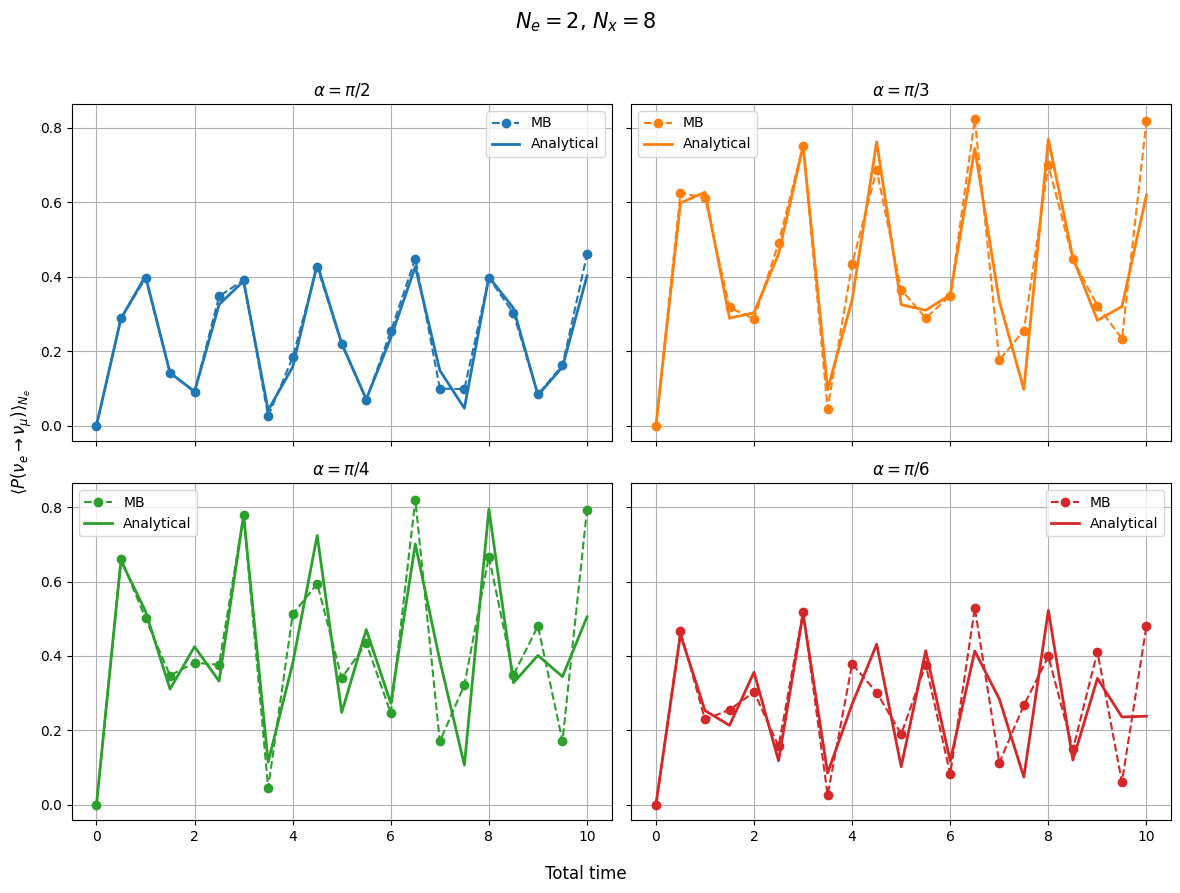

In [22]:
alpha_cases = [
    (np.pi/2, r"\pi/2"),
    (np.pi/3, r"\pi/3"),
    (np.pi/4, r"\pi/4"),
    (np.pi/6, r"\pi/6"),
]
P_mb = {}
P_emu = {}

fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True, sharey=True)
axes = axes.flatten()

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

for ax, (alpha, alpha_label), color in zip(axes, alpha_cases, colors):

    result = run_and_plot_alpha(
        alpha,
        alpha_label,
        show_plot=False,
    )
    t = np.linspace(0, 200, 20)

    P = collective_oscillation_probability(
        N1=Ne,
        N2=Nx,
        alpha=alpha,
        t=times,
        lam=J
    )
    P_mb[alpha_label] = result["many_body"]["P_e_to_mu_avg"]
    P_emu[alpha_label] = P
   # print(id(P_mb_1_))
    x, xlabel = get_plot_time()

    ax.plot(x, P_mb[alpha_label], "--o", color=color, label="MB")
    ax.plot(x, P_emu[alpha_label], "-", lw=2, color=color, label="Analytical")

    ax.set_title(rf"$\alpha={alpha_label}$")
    ax.grid(True)
    ax.legend()

fig.supxlabel(xlabel)
fig.supylabel(r"$\langle P(\nu_e\to\nu_\mu)\rangle_{N_e}$")
fig.suptitle(rf"$N_e={Ne}$, $N_x={Nx}$", fontsize=15)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## 